In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [16]:
final_dataset = pd.read_csv('final_dataset.csv')
encoded_cols = []
for cols in final_dataset.columns:
    match = re.match(r'[A-D][0-9]+\.+[0-9]*\.*', cols)
    if match:
        encoded_cols.append(match.group())
encoded_cols.append('Risk Rating')

final_dataset = pd.read_csv('final_dataset.csv', dtype={col: 'category' for col in encoded_cols})
final_dataset.rename(columns={'index': 'Company'}, inplace=True)

In [17]:
for cols in final_dataset.columns:
    if cols == 'Company':
        continue
    if cols not in encoded_cols:
        final_dataset[cols] = pd.to_numeric(final_dataset[cols].replace({'\.': '', ',': ''}, regex=True), errors='coerce')

# Function to convert all categorical columns to ordered categorical
def convert_to_ordered_categorical(df):
    # Iterate through each column in the dataframe
    for column in df.select_dtypes(include=['category']).columns:
        # Convert categorical columns to ordered categorical
        df[column] = df[column].cat.as_ordered()
    return df

final_dataset = convert_to_ordered_categorical(final_dataset)

In [18]:
print(final_dataset.isnull().sum().to_string())

Company                                                                                             0
A1.1.                                                                                               0
A1.2.                                                                                               0
A2.1.                                                                                               0
A2.2.                                                                                               0
A2.3.                                                                                               0
A2.4.                                                                                               0
A3.1.                                                                                               0
A3.2.                                                                                               0
A3.3.                                                                             

In [19]:
print(final_dataset.dtypes.to_string())

Company                                                                                               object
A1.1.                                                                                               category
A1.2.                                                                                               category
A2.1.                                                                                               category
A2.2.                                                                                               category
A2.3.                                                                                               category
A2.4.                                                                                               category
A3.1.                                                                                               category
A3.2.                                                                                               category
A3.3.              

In [20]:
for i in final_dataset[final_dataset['Company'] == 'AKBNK.E']:
    print(i, final_dataset[final_dataset['Company'] == 'AKBNK.E'][i].to_string())

Company 2    AKBNK.E
A1.1. 2    11
Categories (2, object): ['10' < '11']
A1.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.1. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.3. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.4. 2    11
Categories (2, object): ['10' < '11']
A3.1. 2    11
Categories (2, object): ['10' < '11']
A3.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A3.3. 2    11
Categories (4, object): ['00' < '01' < '10' < '11']
A4.1. 2    11
Categories (4, object): ['00' < '01' < '10' < '11']
B1. 2    11
Categories (2, object): ['10' < '11']
B2. 2    11
Categories (2, object): ['01' < '11']
B4. 2    11
Categories (3, object): ['01' < '10' < '11']
B5. 2    11
Categories (3, object): ['01' < '10' < '11']
B7. 2    11
Categories (3, object): ['01' < '10' < '11']
B8. 2    11
Categories (3, object): ['01' < '10' < '11']
B9. 2    11
Categories (2, object): ['10' < '11']
B10. 2    11
Categ

In [21]:
print(f"Numbers of rows: {final_dataset.shape[0]}")
print(f"Numbers of columns: {final_dataset.shape[1]}")

Numbers of rows: 67
Numbers of columns: 539


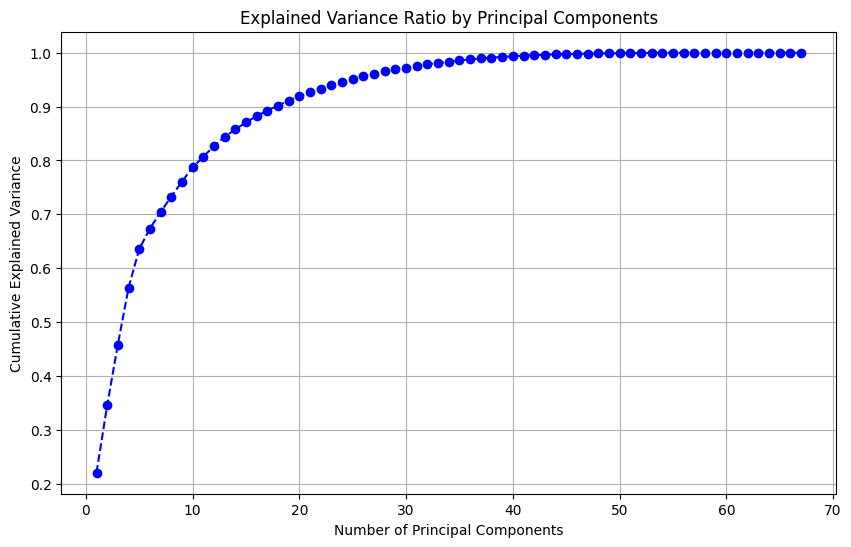

In [22]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca_and_plot(X, n_components=None):
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot the explained variance ratio
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_.cumsum(), 
        marker='o', linestyle='--', color='b'
    )
    plt.title('Explained Variance Ratio by Principal Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()
    
    return X_pca, pca

# Example Usage
# Assuming your dataset is `final_dataset` and target column is 'target'
target_column = "ESG Score"  # Replace with your target column name
X = final_dataset.drop(columns=[target_column, 'Company'])  # Exclude target and non-numerical identifier columns
y = final_dataset[target_column]

# Perform PCA and plot
X_pca, pca = perform_pca_and_plot(X)

<h1> Raw Model Results

In [23]:
variance_threshold = 0.999999

Applying PCA for 0.999999% explained variance...
Number of components selected for 99.9999% explained variance: 62
Training and evaluating models...
Training Linear Regression...


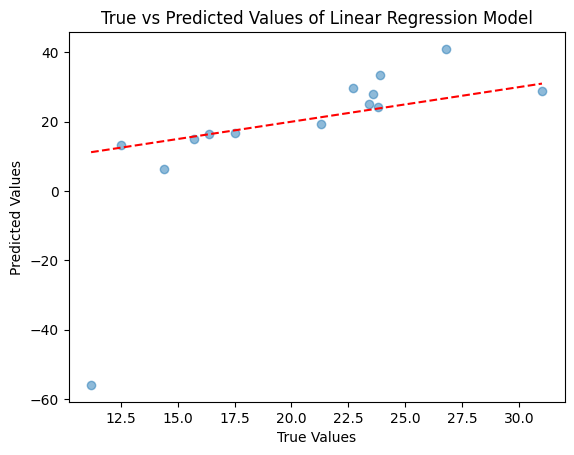

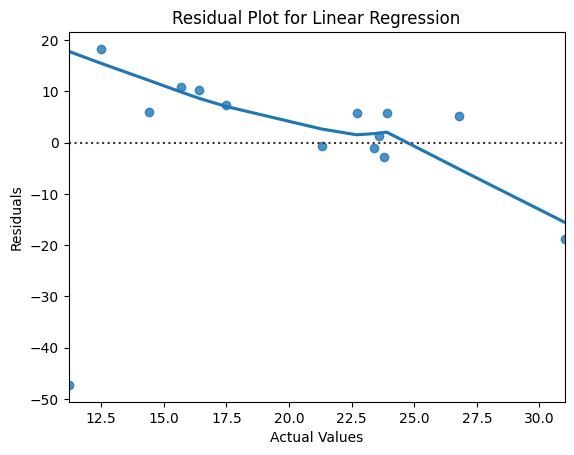

Training Lasso Regression...


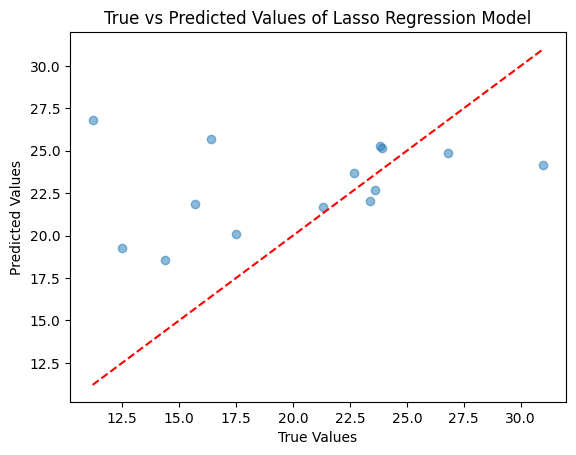

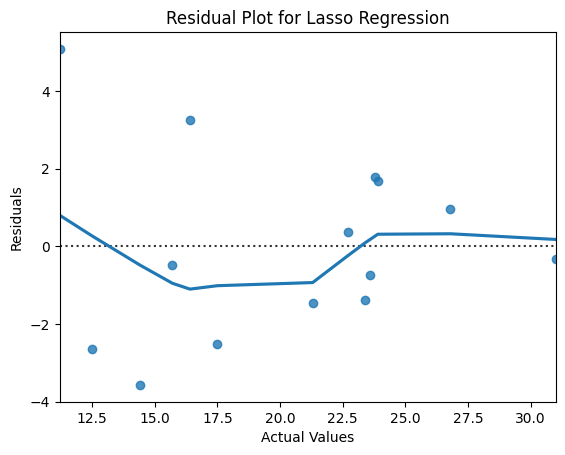

Training Ridge Regression...


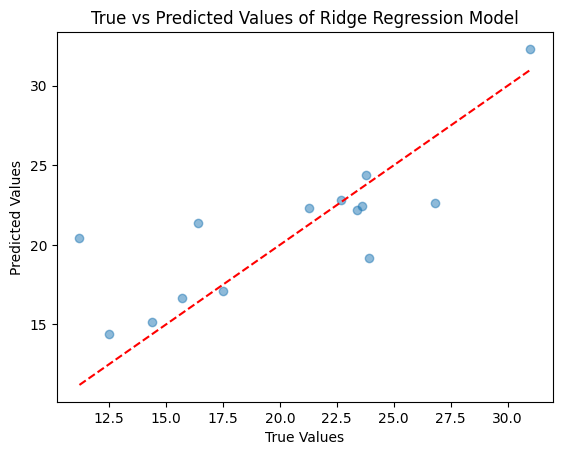

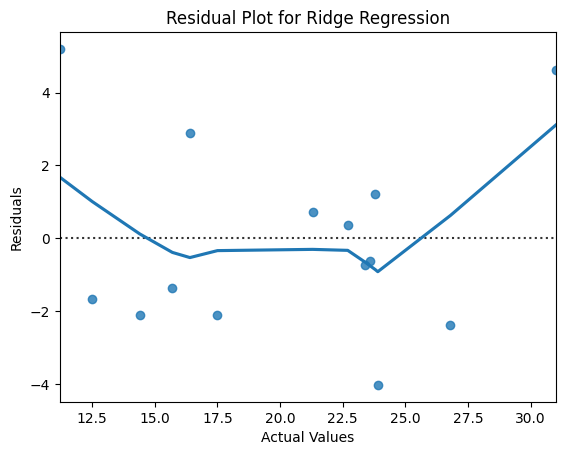

Training Random Forest...


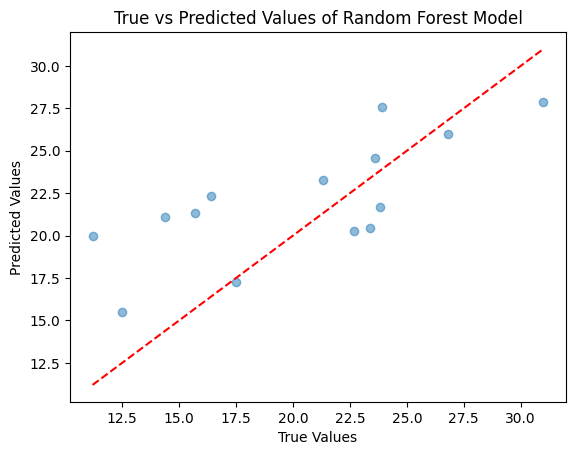

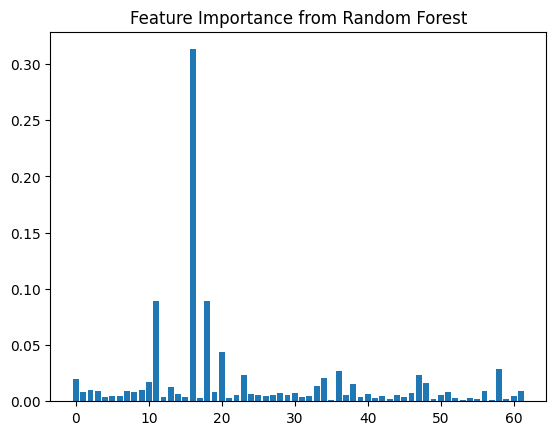

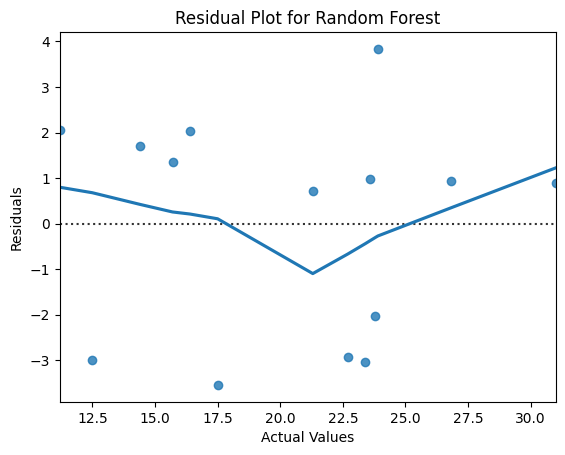

Training Gradient Boosting...


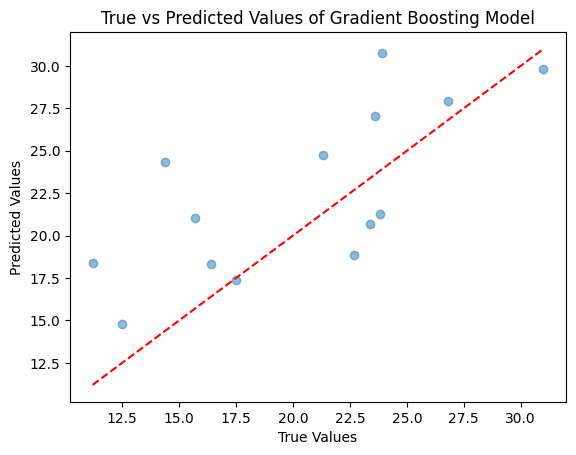

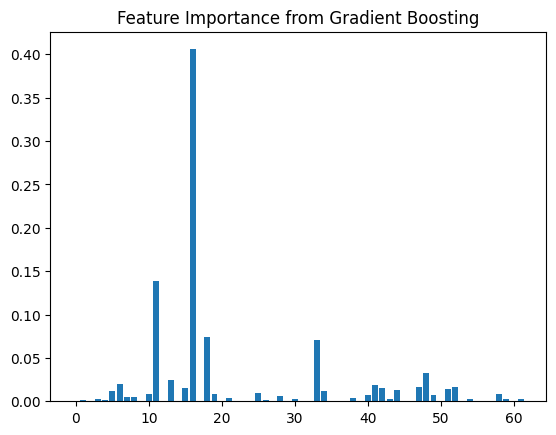

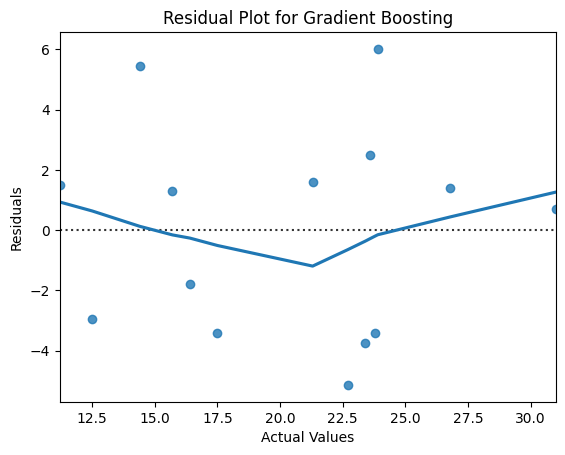

Training Support Vector Regressor (SVR)...


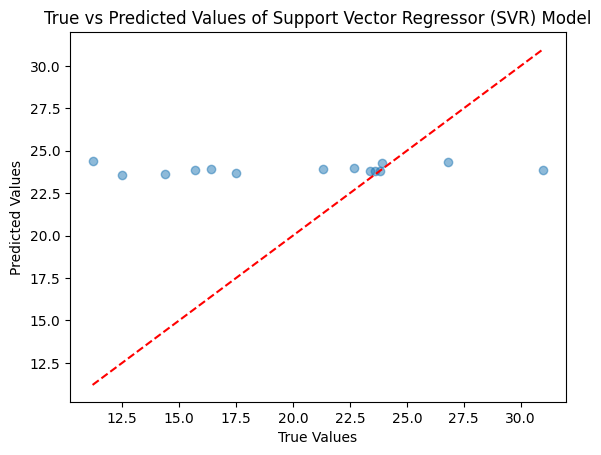

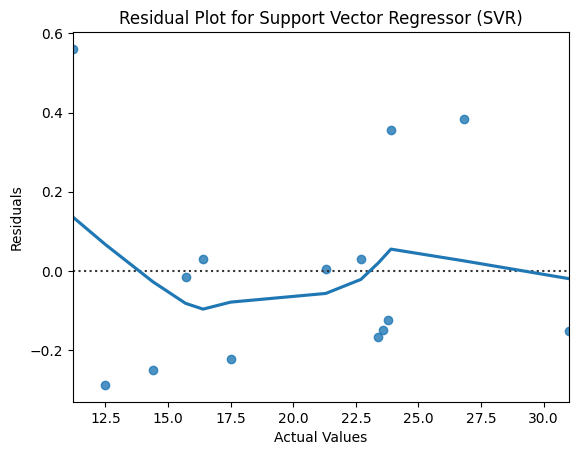

Training K-Nearest Neighbors (KNN)...


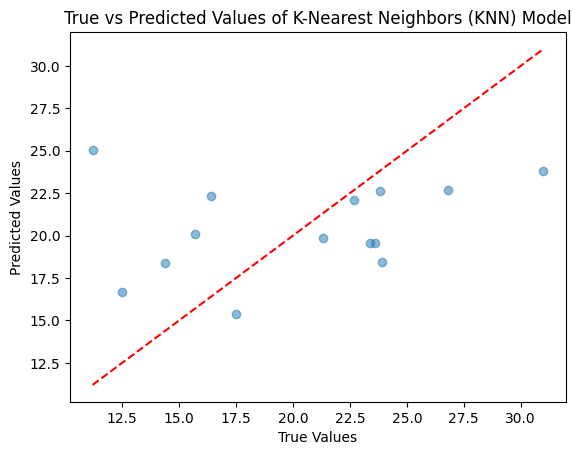

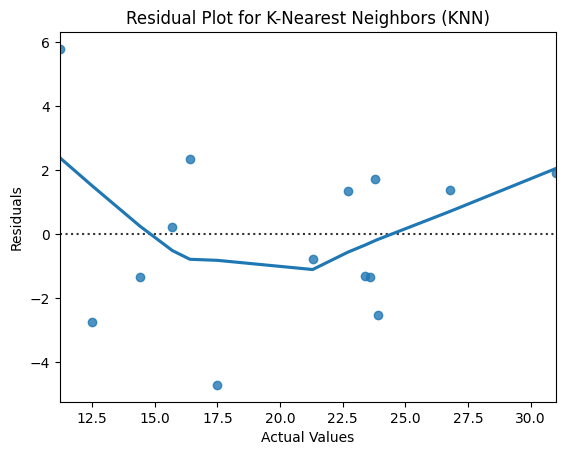


Model Evaluation Results:
                            Model         MSE       MAE   R² Score
0               Linear Regression  353.628703  8.496549 -10.463374
1                Lasso Regression   35.350605  4.261149  -0.145940
2                Ridge Regression   11.461344  2.321998   0.628464
3                   Random Forest   17.501377  3.447286   0.432668
4               Gradient Boosting   20.710810  3.708612   0.328630
5  Support Vector Regressor (SVR)   43.574545  4.993074  -0.412530
6       K-Nearest Neighbors (KNN)   29.863371  4.451429   0.031937


In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve 90% explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train and Evaluate Models
def evaluate_models(X_train, X_test, y_train, y_test):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(alpha=1.0),  # Lasso regression with default alpha
        "Ridge Regression": Ridge(alpha=1.0),  # Ridge regression with default alpha
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(kernel='rbf'),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor(n_neighbors=5)
    }
    
    results = []
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title("True vs Predicted Values of {} Model".format(name))
        plt.show()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot Feature Importances if applicable
        try:
            feature_importances = model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass
        
        # Residual Plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        results.append({
            "Model": name,
            "MSE": mse,
            "MAE": mae,
            "R² Score": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset
    
    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df["ESG Score"]

    # Apply PCA
    print(f"Applying PCA for {variance_threshold}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Train and evaluate models
    print("Training and evaluating models...")
    results = evaluate_models(X_train, X_test, y_train, y_test)

    # Display results
    print("\nModel Evaluation Results:")
    print(results)

if __name__ == "__main__":
    main()


<H1> Fine-Tune Added

Applying PCA for 0.999999% explained variance...
Number of components selected for 99.9999% explained variance: 62
Training and evaluating models with tuning...
Training and tuning Linear Regression...


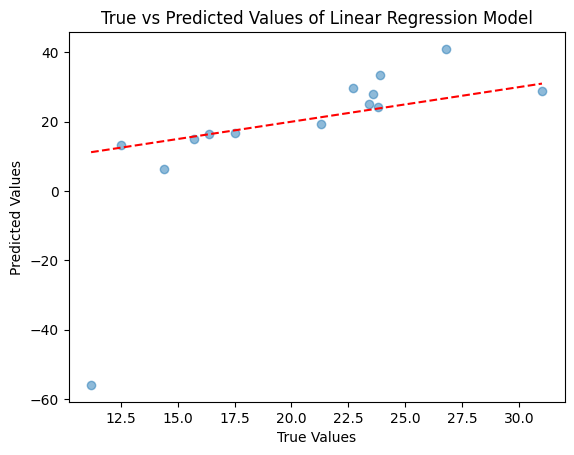

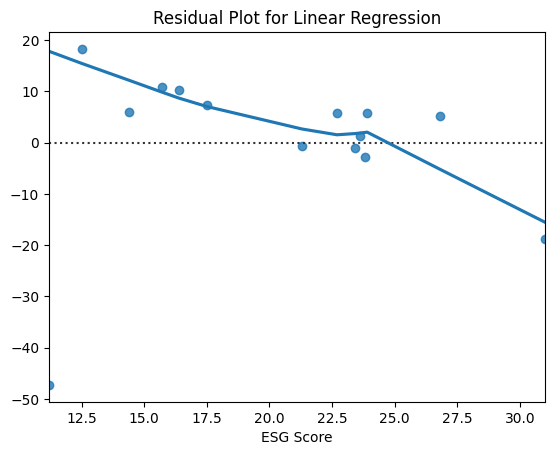

Training and tuning Lasso Regression...
Best params for Lasso Regression: {'alpha': 0.01}


/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.818e+00, tolerance: 1.871e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.157e-01, tolerance: 1.876e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

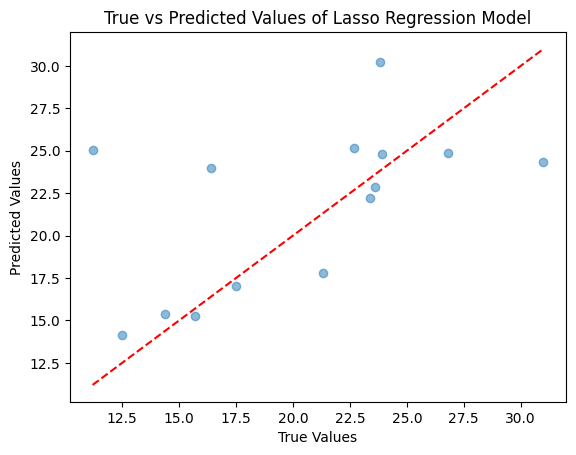

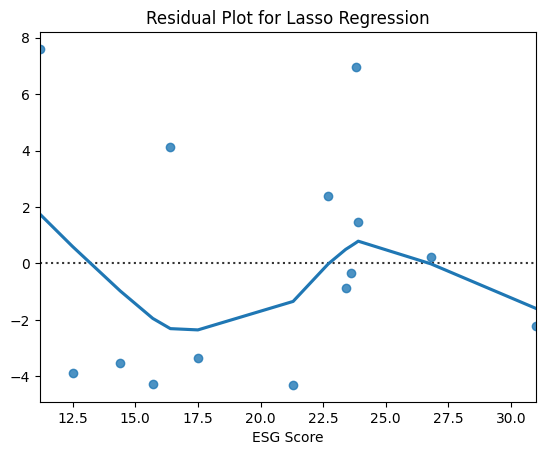

Training and tuning Ridge Regression...
Best params for Ridge Regression: {'alpha': 0.01}


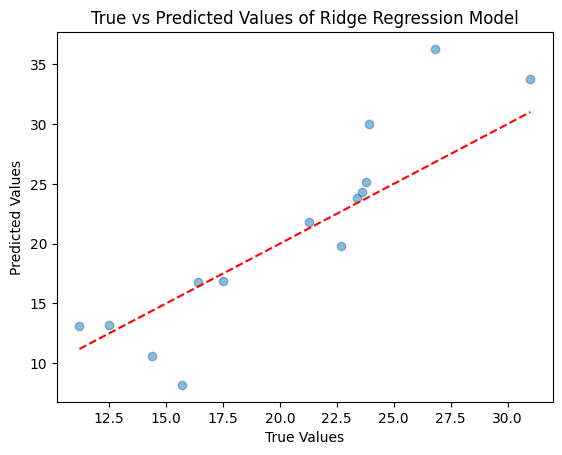

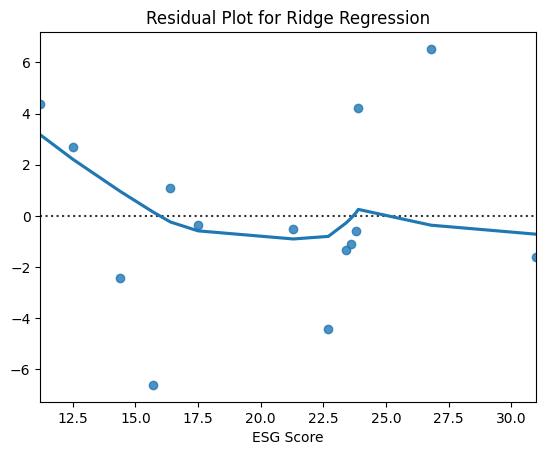

Training and tuning Random Forest...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


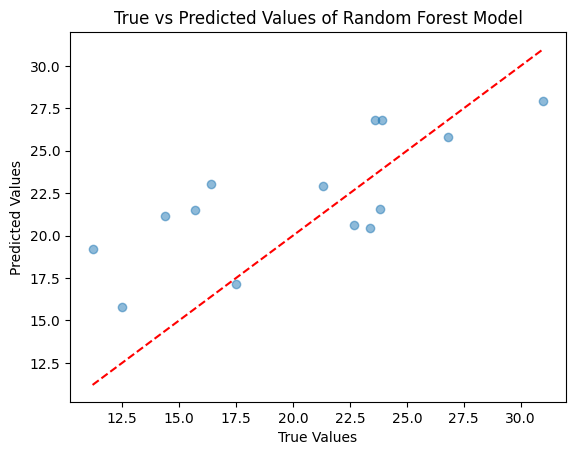

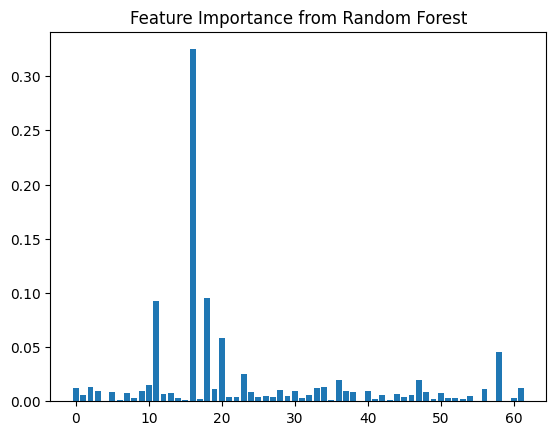

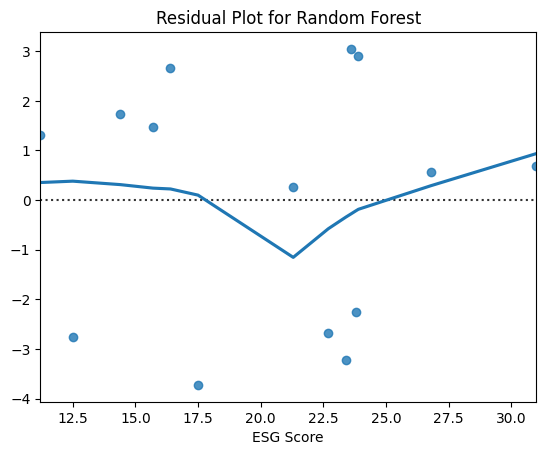

Training and tuning Gradient Boosting...
Best params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


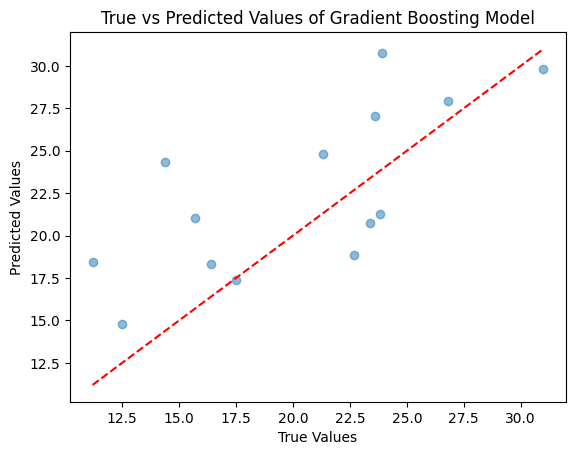

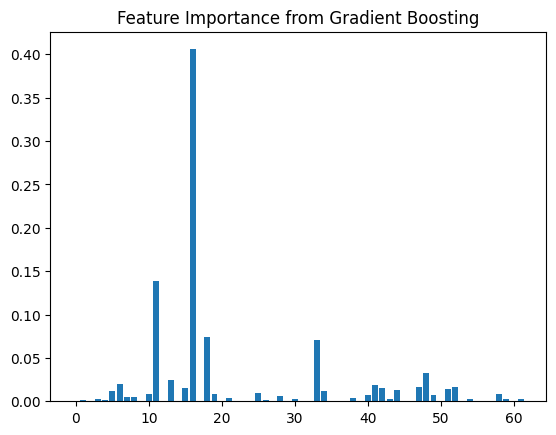

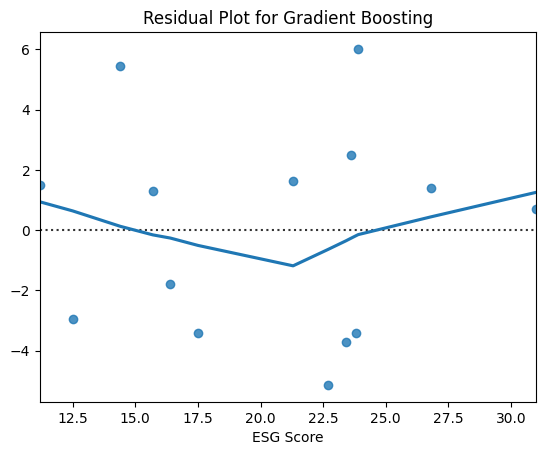

Training and tuning Support Vector Regressor (SVR)...


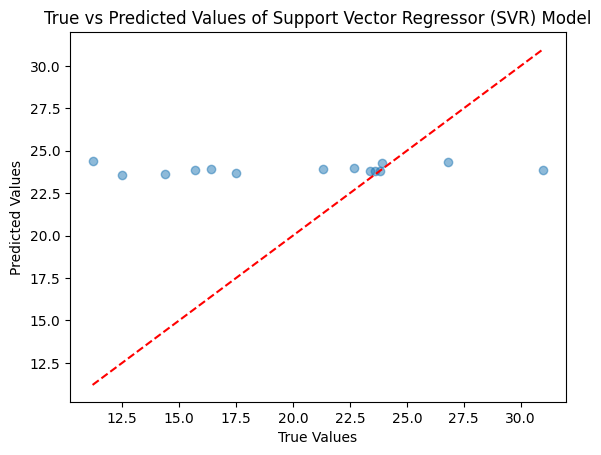

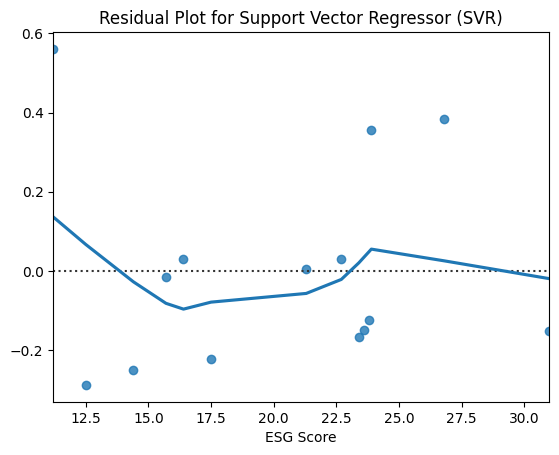

Training and tuning K-Nearest Neighbors (KNN)...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 3, 'weights': 'distance'}


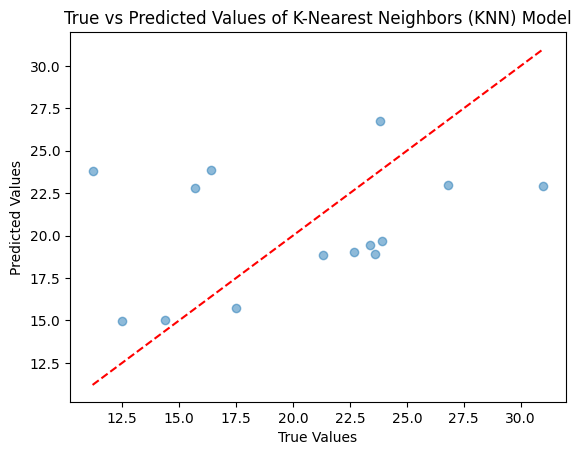

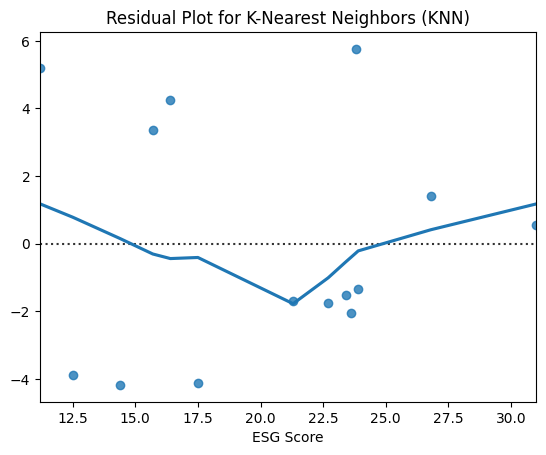


Model Evaluation Results:
                            Model         MSE       MAE   R² Score
0               Linear Regression  353.628703  8.496549 -10.463374
1                Lasso Regression   26.002377  3.485862   0.157096
2                Ridge Regression   15.825525  2.803961   0.486993
3                   Random Forest   17.738395  3.563322   0.424985
4               Gradient Boosting   20.735480  3.708924   0.327830
5  Support Vector Regressor (SVR)   43.574545  4.993074  -0.412530
6       K-Nearest Neighbors (KNN)   31.269490  4.707236  -0.013645


In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold=0.90):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve 90% explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models
def evaluate_and_tune_models(X_train, X_test, y_train, y_test):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Ridge Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []
    
    for name, model in models.items():
        print(f"Training and tuning {name}...")
        
        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=3, scoring='neg_mean_squared_error')
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title("True vs Predicted Values of {} Model".format(name))
        plt.show()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_ 
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass
        
        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "MSE": mse,
            "MAE": mae,
            "R² Score": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():

    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset
    
    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    # Apply PCA
    print(f"Applying PCA for {variance_threshold}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and tune models
    print("Training and evaluating models with tuning...")
    results = evaluate_and_tune_models(X_train, X_test, y_train, y_test)

    # Display results
    print("\nModel Evaluation Results:")
    print(results)

if __name__ == "__main__":
    main()


<h1> Cross-Validation Added

Applying PCA for 99.9999% explained variance...
Number of components selected for 99.9999% explained variance: 62
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...


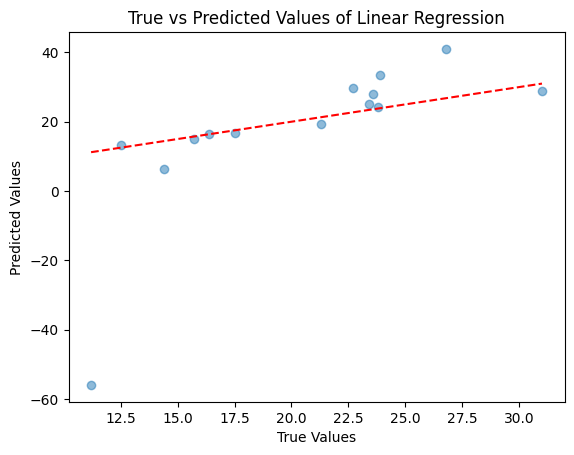

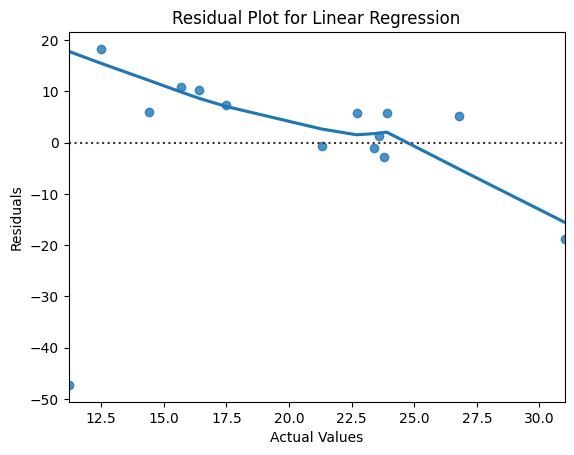

Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 0.01}


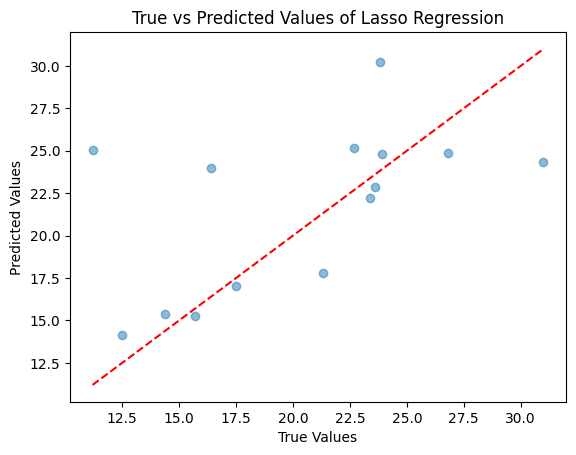

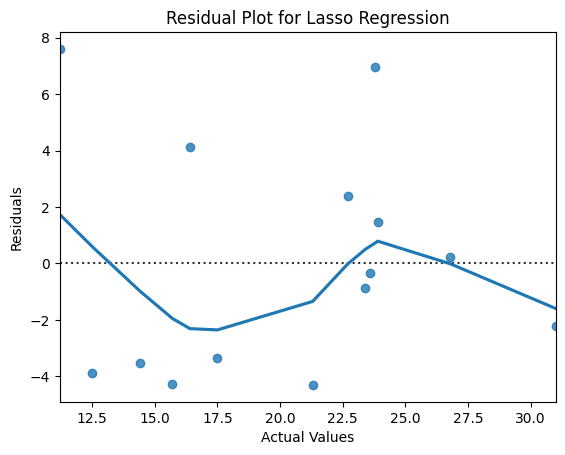

Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 0.1}


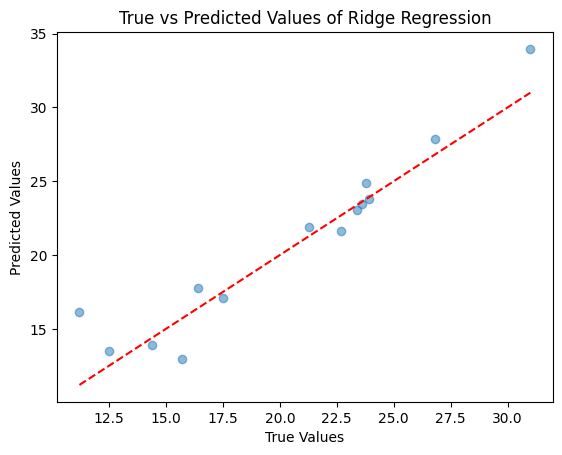

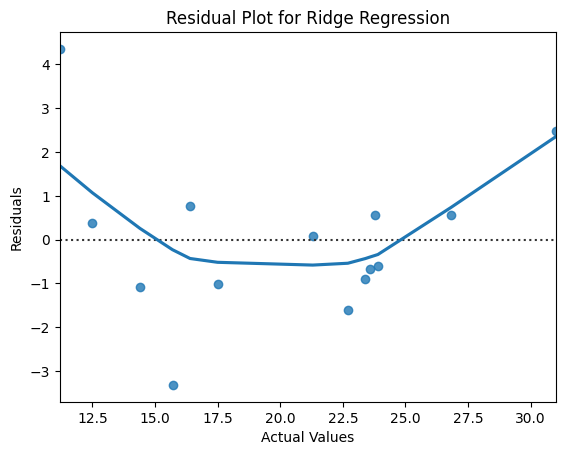

Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


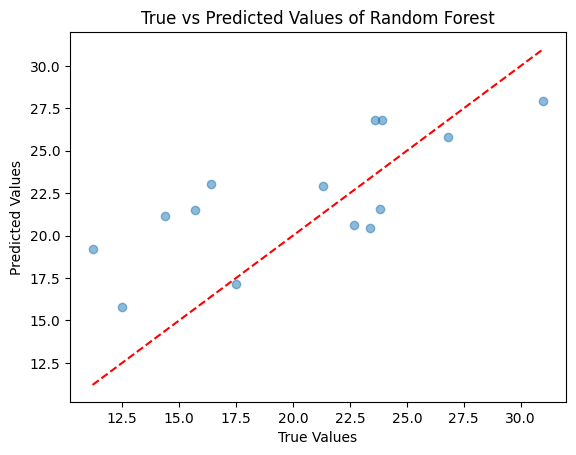

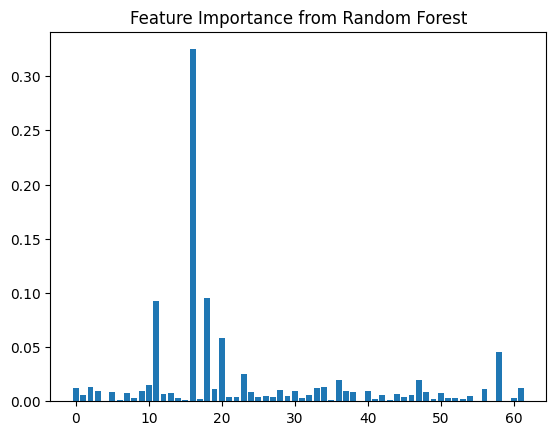

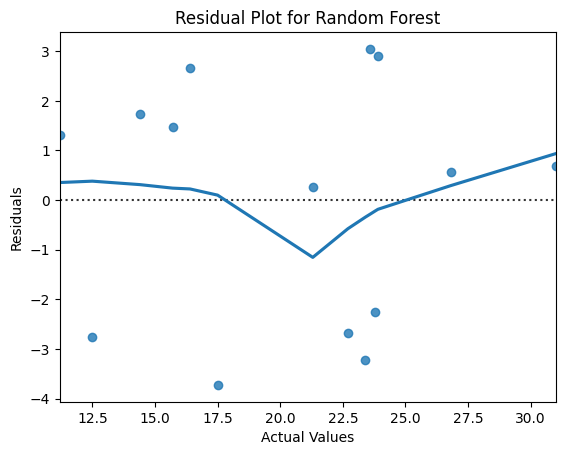

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


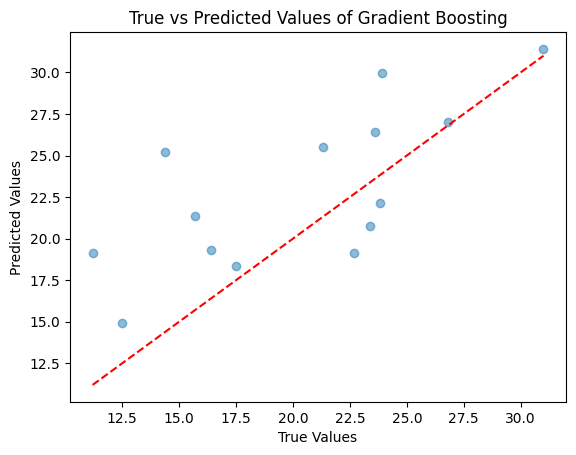

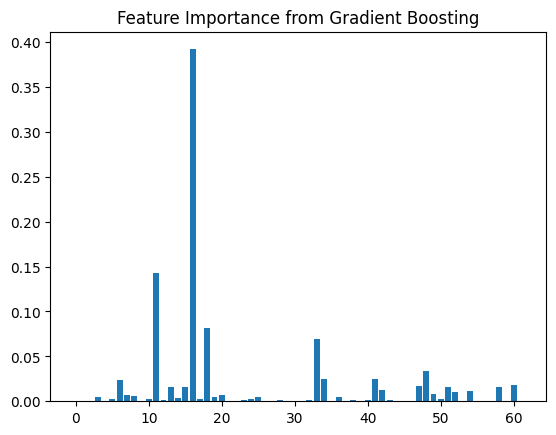

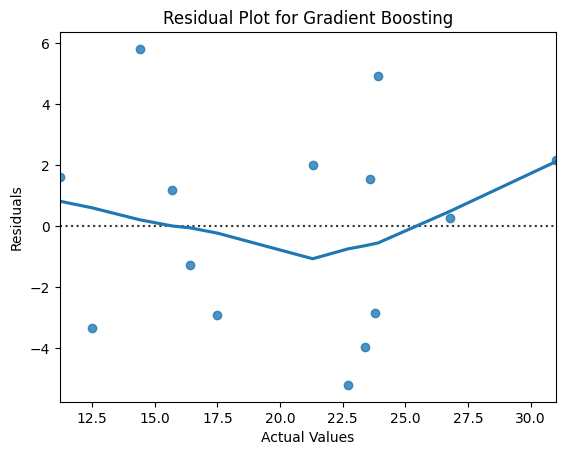

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


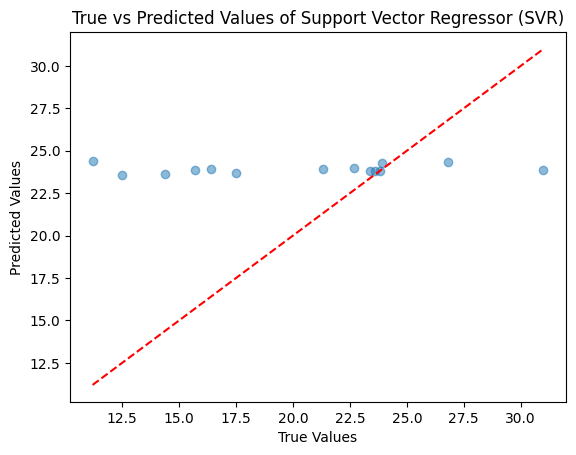

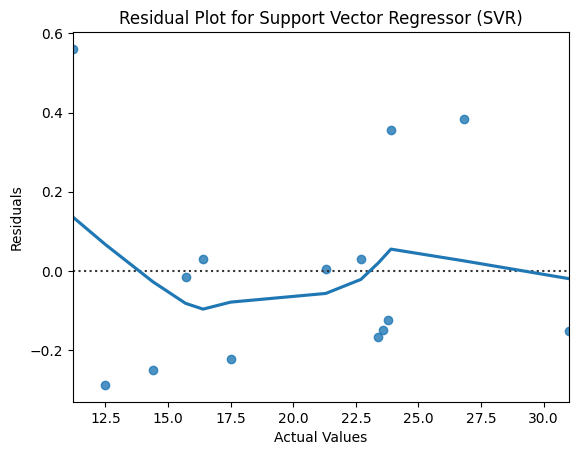

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 3, 'weights': 'distance'}


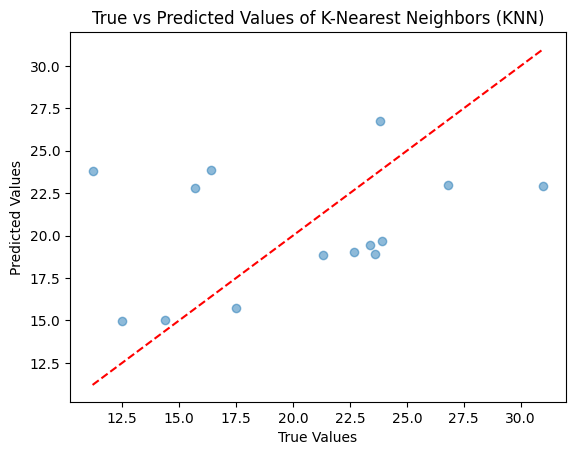

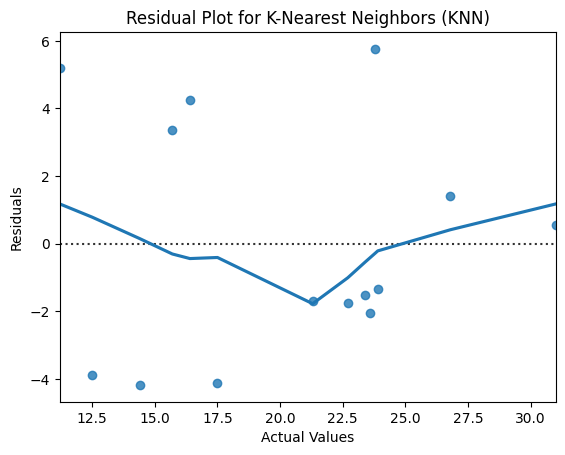


Model Evaluation Results with Cross-Validation:
                            Model  Avg CV MSE    Test MSE  Test MAE    Test R²
0               Linear Regression   53.292496  353.628703  8.496549 -10.463374
1                Lasso Regression   19.564230   26.002377  3.485862   0.157096
2                Ridge Regression   12.000534    3.432556  1.310801   0.888729
3                   Random Forest   30.984434   17.738395  3.563322   0.424985
4               Gradient Boosting   30.751593   22.255811  3.725168   0.278546
5  Support Vector Regressor (SVR)   57.491200   43.574545  4.993074  -0.412530
6       K-Nearest Neighbors (KNN)   38.171715   31.269490  4.707236  -0.013645


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve the specified explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Ridge Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    print(f"Applying PCA for {variance_threshold * 100}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()


<h1> Train-Test Accuracy Plots Added

Applying PCA for 99.9999% explained variance...
Number of components selected for 99.9999% explained variance: 62
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...
Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 0.01}
Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 0.1}
Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...
Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neigh

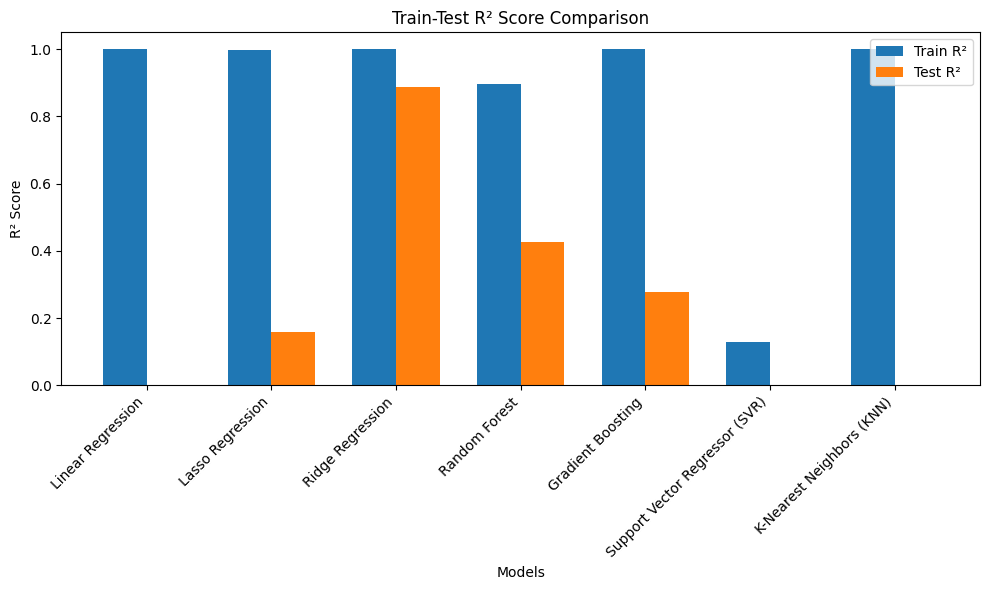


Train-Test R² Score Comparison:
                            Model  Train R²    Test R²
0               Linear Regression  1.000000 -10.463374
1                Lasso Regression  0.998465   0.157096
2                Ridge Regression  0.999621   0.888729
3                   Random Forest  0.895495   0.424985
4               Gradient Boosting  1.000000   0.278546
5  Support Vector Regressor (SVR)  0.127452  -0.412530
6       K-Nearest Neighbors (KNN)  1.000000  -0.013645


In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve the specified explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_compare_models(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Ridge Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {"C": [1, 10, 100], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]},
        "K-Nearest Neighbors (KNN)": {"n_neighbors": [3, 5, 10], "weights": ["uniform", "distance"]}
    }
    
    train_r2_scores = []
    test_r2_scores = []
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Calculate train and test \( R^2 \) scores
        train_r2 = best_model.score(X_train, y_train)
        test_r2 = best_model.score(X_test, y_test)

        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        # Store results
        results.append({"Model": name, "Train R²": train_r2, "Test R²": test_r2})

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    # Plot train and test \( R^2 \) scores
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    indices = np.arange(len(models))

    # Make negative r^2 values 0
    train_r2_scores = np.maximum(train_r2_scores, 0)
    test_r2_scores = np.maximum(test_r2_scores, 0)

    plt.bar(indices, train_r2_scores, bar_width, label='Train R²')
    plt.bar(indices + bar_width, test_r2_scores, bar_width, label='Test R²')

    plt.xlabel('Models')
    plt.ylabel('R² Score')
    plt.title('Train-Test R² Score Comparison')
    plt.xticks(indices + bar_width / 2, models.keys(), rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["Company", 'ESG Score'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    print(f"Applying PCA for {variance_threshold * 100}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and compare models
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_compare_models(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nTrain-Test R² Score Comparison:")
    print(results)

if __name__ == "__main__":
    main()


<h1> LLE, UMAP, ISOMAP REDUCTION TECHNİQUES IMPLEMENTED

Applying Lle for dimensionality reduction...
Lle reduced data to 50 components.
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...


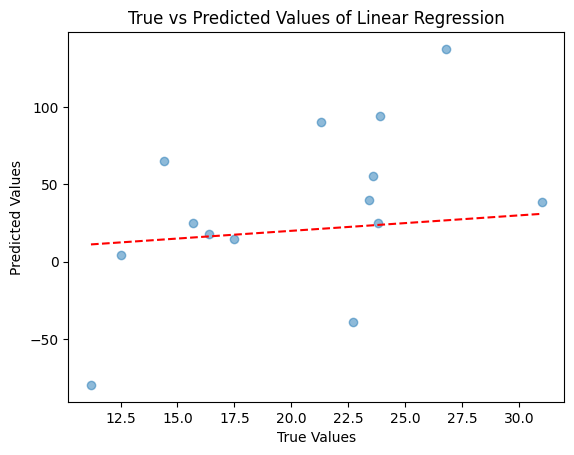

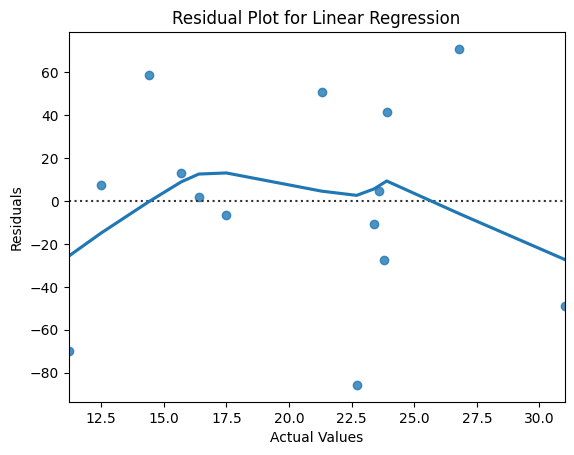

Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 0.1}


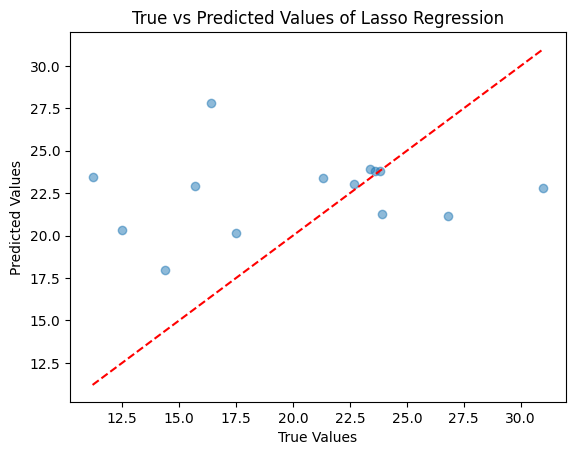

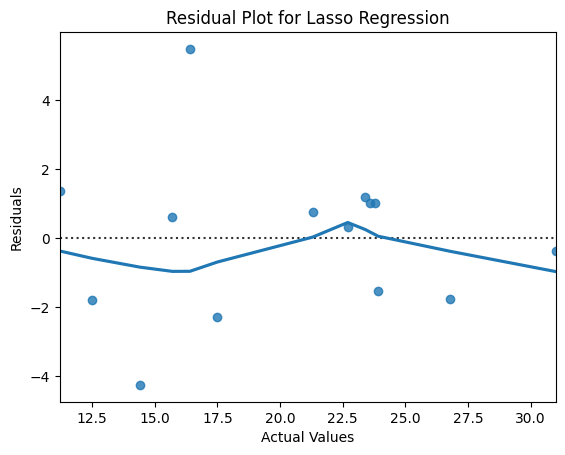

Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 1.0}


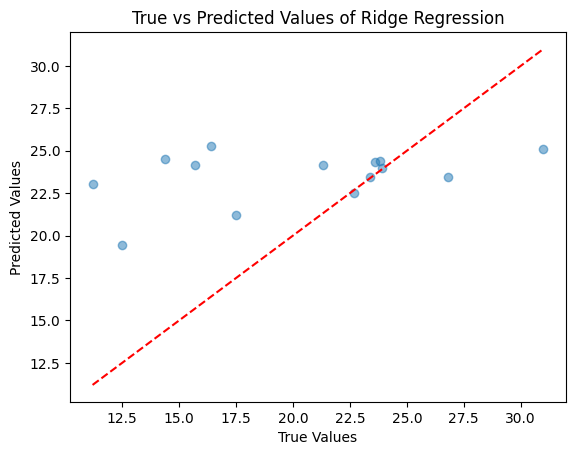

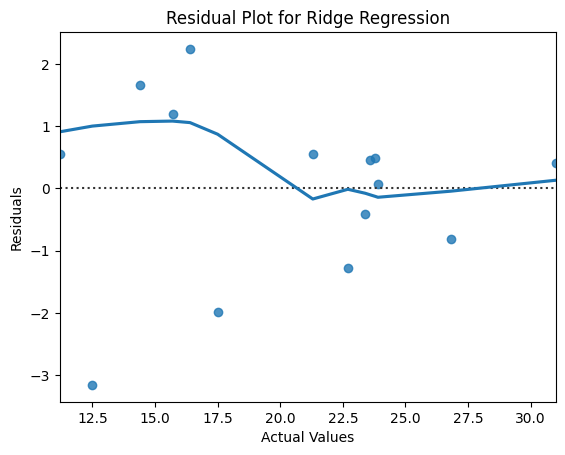

Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


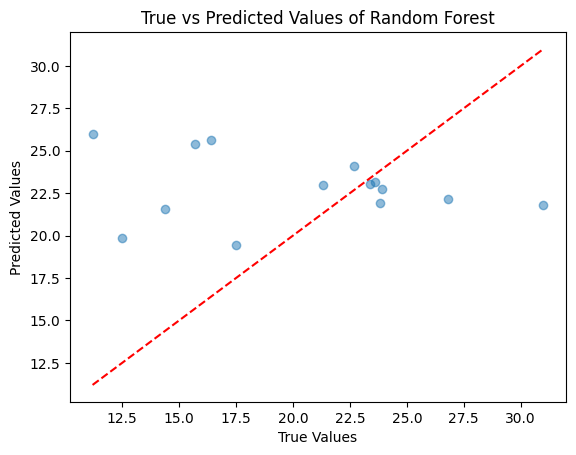

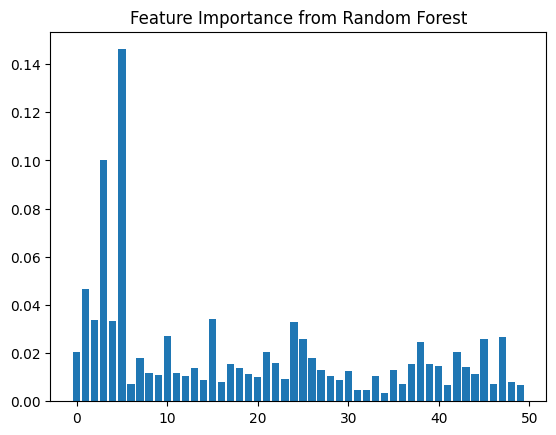

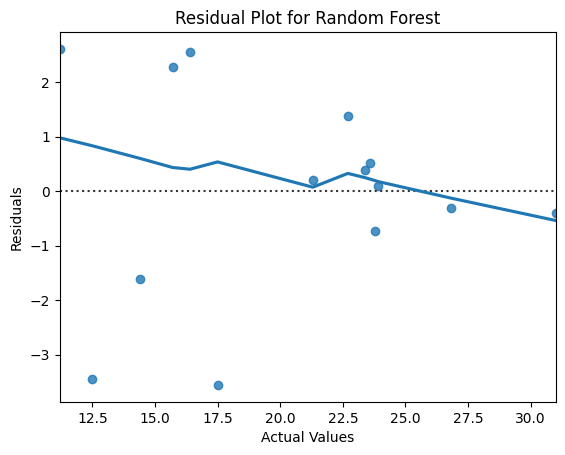

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


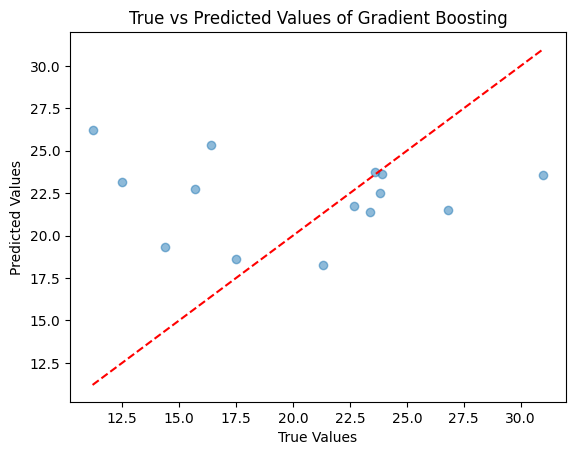

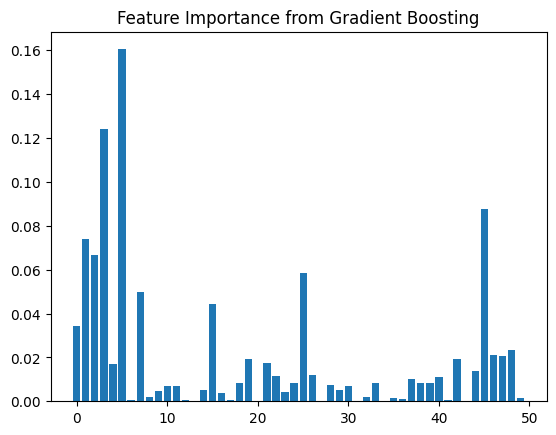

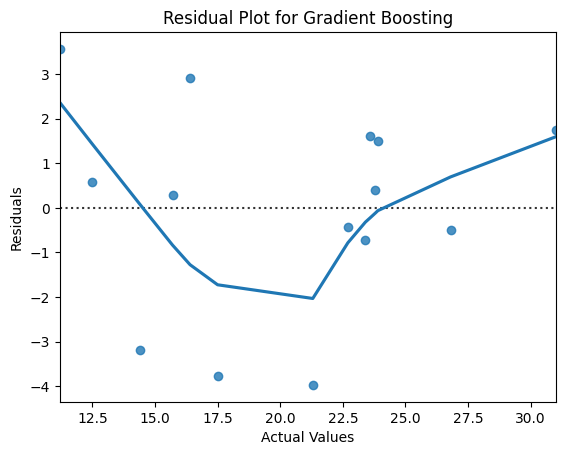

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


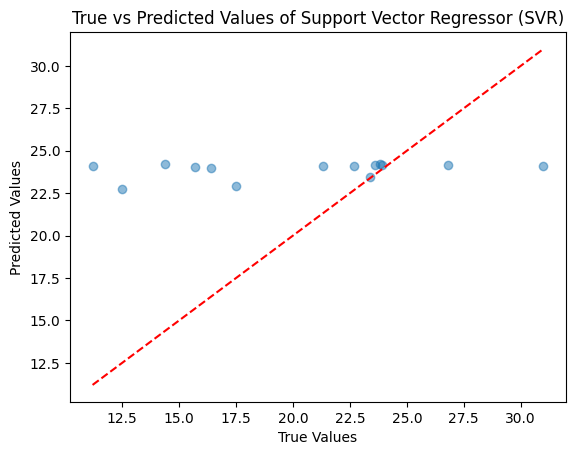

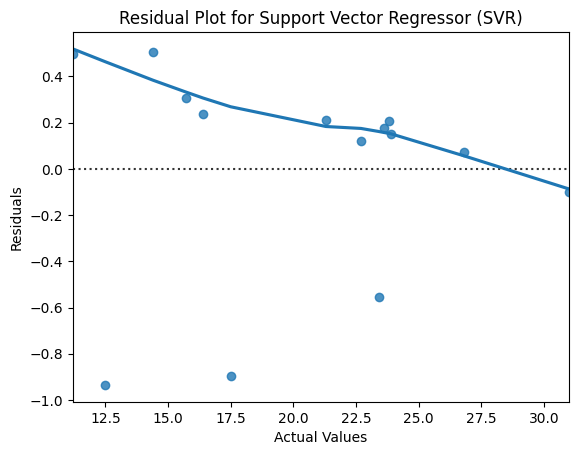

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 5, 'weights': 'distance'}


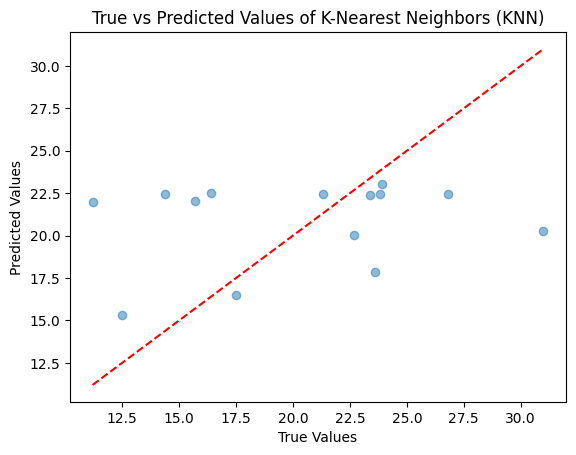

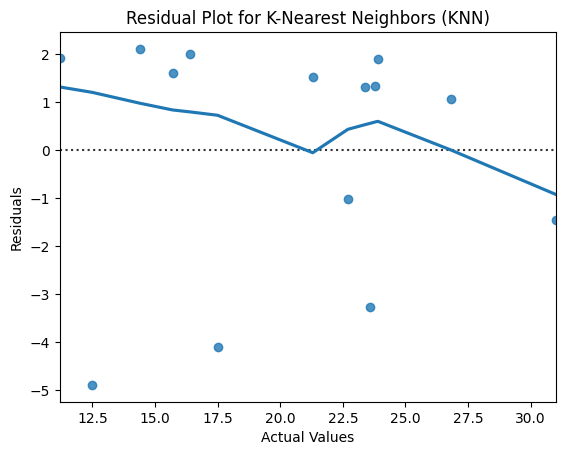


Model Evaluation Results with Cross-Validation:
                            Model  Avg CV MSE     Test MSE   Test MAE  \
0               Linear Regression  341.674894  2726.311195  38.035375   
1                Lasso Regression   55.084270    37.489299   4.616100   
2                Ridge Regression   50.153309    36.346673   4.545541   
3                   Random Forest   49.952976    44.389612   5.060071   
4               Gradient Boosting   45.248136    42.393015   4.866943   
5  Support Vector Regressor (SVR)   55.576086    42.122192   4.951327   
6       K-Nearest Neighbors (KNN)   68.424399    31.909427   4.494747   

     Test R²  
0 -87.377227  
1  -0.215269  
2  -0.178229  
3  -0.438952  
4  -0.374229  
5  -0.365450  
6  -0.034389  


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding

# Step 1: Preprocess Data and Apply Dimensionality Reduction
def preprocess_and_apply_reduction(X, target, method='umap', n_components=2):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply different dimensionality reduction methods based on 'method'
    if method == 'umap':
        import umap
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == 'isomap':
        reducer = Isomap(n_components=n_components)
    elif method == 'lle':
        reducer = LocallyLinearEmbedding(n_components=n_components)

    # Apply dimensionality reduction
    X_reduced = reducer.fit_transform(X_scaled)

    print(f"{method.capitalize()} reduced data to {n_components} components.")
    
    return X_reduced, target, reducer

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    param_grids = {
        "Lasso Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Ridge Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    # Select dimensionality reduction method: 'umap', 'isomap', or 'lle'
    method = 'lle'  # Change this to 'lle' or 'umap' as needed

    print(f"Applying {method.capitalize()} for dimensionality reduction...")
    X_reduced, y, reducer = preprocess_and_apply_reduction(X, y, method=method, n_components=50)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()